## Question: "How long do I need to integrate to detect a faint redshifted emission line at a target S/N?"

### Some NIRSpec Docs
- [Readout Patterns](https://jwst-docs.stsci.edu/jwst-near-infrared-spectrograph/nirspec-instrumentation/nirspec-detectors/nirspec-detector-readout-modes-and-patterns#gsc.tab=0)
- [Recommended Strategies](https://jwst-docs.stsci.edu/jwst-near-infrared-spectrograph/nirspec-observing-strategies/nirspec-detector-recommended-strategies#gsc.tab=0)

In [4]:
# Pandeia reference data
import os
os.environ["pandeia_refdata"] = "../../data/pandeia_data-2026.7-jwst"
os.environ["PSF_DIR"] = "../../data/pandeia_psfs-2026.7rc1-jwst"
os.environ["PYSYN_CDBS"] = "../../data/grp/redcat/trds"

# Exposure time calculator
from pandeia.engine.calc_utils import build_default_calc
from pandeia.engine.perform_calculation import perform_calculation

import matplotlib.pyplot as plt
import numpy as np

# Observing parameters
telescope = 'jwst'
instrument = 'nirspec'
mode = 'fixed_slit'
disperser = 'g395m'
filter = 'f290lp'
readout_pattern = 'nrsirs2' # IRS2 patterns are recommended for faint targets (lowest read noise)

# Tuning exposure parameters
min_groups = 5 # min 5 recommended
max_groups = 190 # max 190 recommended
min_nint = 1
max_nint = 10 # max allowed

nexp = 3 # N exposures 
group_step = 20 # group step size for S/N calculation

# Science goal
target_line_snr = 30.0 # required integrated line S/N
geometry = 'point' # source geometry

# Emission line
name = 'H alpha'
emission_line_center = 0.6563 # rest wavelength, microns
emission_line_width = 1000 # km/s FWHM
emission_line_strength = 2e-18 # erg/s/cm2 (integrated line flux)
redshift = 5

c_kms = 299792.458
obs_wavelength = emission_line_center * (1 + redshift) # observed-frame line center (um)
sigma_um = obs_wavelength * (emission_line_width / c_kms) / 2.3548  # Gaussian sigma (um)

# Exposure constraints
max_single_int = 1500 # max single integration time, s (limits cosmic-ray hits)
max_single_exp = 10000 # max single exposure time, s

### Functions

In [5]:
def build_calc(ngroup, nint, nexp):
    """Build a calc for the redshifted line at a given readout recipe."""
    calc = build_default_calc(telescope, instrument, mode)
    calc['configuration']['instrument']['disperser'] = disperser
    calc['configuration']['instrument']['filter'] = filter
    calc['configuration']['detector']['readout_pattern'] = readout_pattern
    calc['configuration']['detector']['ngroup'] = ngroup
    calc['configuration']['detector']['nint'] = nint
    calc['configuration']['detector']['nexp'] = nexp
    calc['background_level'] = 'low'

    scene = calc['scene'][0]
    scene['shape']['geometry'] = geometry
    scene['spectrum']['sed'] = {'sed_type': 'no_continuum'} # zero continuum (no normalization needed).
    scene['spectrum']['redshift'] = 0
    scene['spectrum']['lines'] = [{
        'id': 0, 
        'name': name, 
        'emission_or_absorption': 'emission',
        'center': obs_wavelength, # line at its observed redshifted wavelength
        'width': emission_line_width, # km/s FWHM
        'strength': emission_line_strength, 
        'profile': 'gaussian'}]
    return calc

def integrated_line_snr(report, nsigma=3.0):
    """Continuum-subtracted integrated S/N over a fixed +/- nsigma line window.

    Sums the (continuum-subtracted) flux across the line and divides by the
    quadrature-summed noise. The window is fixed and signal-independent, so the
    S/N is not biased -- unlike a `flux > noise` selection, which cherry-picks
    the favorable pixels and inflates the result.
    """
    
    # Extract the 1D spectrum and noise from the report
    wave = np.asarray(report['1d']['extracted_flux'][0])
    flux = np.asarray(report['1d']['extracted_flux'][1])
    noise = np.asarray(report['1d']['extracted_noise'][1])
    
    # Define the line window and continuum region
    dist = np.abs(wave - obs_wavelength) # distance from line center (um)
    line = dist <= nsigma * sigma_um # line window
    side = (dist > nsigma * sigma_um) & (dist <= (nsigma + 4) * sigma_um) #
    continuum = np.median(flux[side]) if side.any() else 0.0 # local baseline
    
    # Compute the integrated line S/N
    signal = np.sum(flux[line] - continuum)
    noise = np.sqrt(np.sum(noise[line] ** 2))
    snr = signal / noise
    return snr


def solve_time_for_line_snr(target_snr, min_groups, max_groups, group_step,
                            min_nint, max_nint, nexp, max_single_int,
                            t_group=None, t_estimate=None, prune=0.7):
    """Smallest-time (nint, ngroup) recipe reaching integrated line S/N >= target_snr.

    Enumerates (nint, ngroup) recipes at FIXED nexp, orders them by ~increasing
    total time (nint * ngroup is a good proxy), and evaluates until the target is
    met. Line S/N grows monotonically with time for these faint, unsaturated
    sources, so the first recipe that crosses is the (near-)minimum.

    A recipe is rejected if its SINGLE INTEGRATION exceeds max_single_int -- long
    integrations accumulate cosmic-ray hits. Since single_int = ngroup * t_group,
    that is purely a limit on ngroup.

    If the sqrt(t) estimate is supplied, recipes far too short to ever reach the
    target are skipped without calling the engine, which saves most of the search.
    """
    # ngroup grid: stepped, but always including max_groups
    ngroup_grid = sorted(set(list(range(min_groups, max_groups + 1, group_step))
                             + [max_groups]))
    recipes = [(ni, ng) for ni in range(min_nint, max_nint + 1) for ng in ngroup_grid]
    recipes.sort(key=lambda r: (r[0] * r[1], r[0]))  # cheaper (shorter) first

    n_skipped_int = 0
    for nint, ngroup in recipes:

        # Cheap pre-filters using the predicted timing (no engine call)
        if t_group is not None:
            if ngroup * t_group > max_single_int:
                n_skipped_int += 1
                continue # single integration would be too long
            if t_estimate is not None and \
                    nexp * nint * ngroup * t_group < prune * t_estimate:
                continue # far too short to reach the target

        report = perform_calculation(build_calc(ngroup, nint, nexp))
        spec = report['information']['exposure_specification']
        single_int = spec['exposure_time'] / nint # per-integration time (s)

        # Enforce the limit against the engine's own timing
        if single_int > max_single_int:
            n_skipped_int += 1
            continue

        snr = integrated_line_snr(report)
        print(f"[search] nint={nint}, ngroup={ngroup}, "
              f"total_exp={spec['total_exposure_time']:.0f}s, "
              f"single_int={single_int:.0f}s, line S/N={snr:.3f}")

        # Check if reached the target S/N
        if snr >= target_snr:
            if n_skipped_int:
                print(f"[search] ({n_skipped_int} recipes skipped: "
                      f"single integration > {max_single_int}s)")
            return report, snr, ngroup, nint

    return None # target not reachable within the search limits

[estimate] ngroup=190, nint=1, nexp=3 -> 4445s gives line S/N=13.31
[estimate] sqrt(t) scaling => ~22591s needed for line S/N=30.0
[estimate] group time = 7.80s, so ngroup <= 192 keeps a single integration under 1500s

[search] nint=8, ngroup=85, total_exp=15929s, single_int=664s, line S/N=22.043
[search] nint=5, ngroup=145, total_exp=16967s, single_int=1131s, line S/N=25.283
[search] nint=7, ngroup=105, total_exp=17210s, single_int=820s, line S/N=24.074
[search] nint=4, ngroup=185, total_exp=17313s, single_int=1443s, line S/N=26.205
[search] nint=6, ngroup=125, total_exp=17556s, single_int=975s, line S/N=25.138
[search] nint=4, ngroup=190, total_exp=17780s, single_int=1482s, line S/N=26.606
[search] nint=9, ngroup=85, total_exp=17921s, single_int=664s, line S/N=23.380
[search] nint=5, ngroup=165, total_exp=19304s, single_int=1287s, line S/N=27.388
[search] nint=8, ngroup=105, total_exp=19669s, single_int=820s, line S/N=25.735
[search] nint=10, ngroup=85, total_exp=19912s, single_int=6

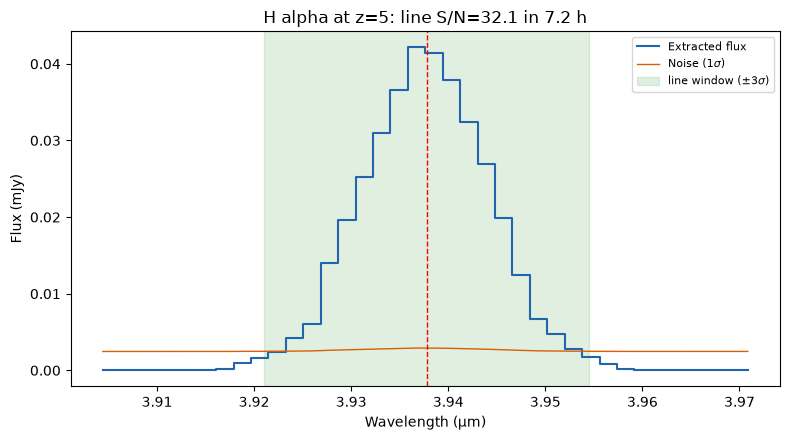

In [6]:
# --- sqrt(t) estimate (also calibrates the group time) ----------------------
# One reference recipe gives both the per-group time and a prediction of the
# total time needed, since line S/N grows as sqrt(time).
ref = perform_calculation(build_calc(max_groups, min_nint, nexp))
spec_ref = ref['information']['exposure_specification']
t_group = spec_ref['exposure_time'] / max_groups # seconds per group
snr_ref = integrated_line_snr(ref)
t_ref = spec_ref['total_exposure_time']
t_estimate = t_ref * (target_line_snr / snr_ref) ** 2

print(f"[estimate] ngroup={max_groups}, nint={min_nint}, nexp={nexp} -> {t_ref:.0f}s "
      f"gives line S/N={snr_ref:.2f}")
print(f"[estimate] sqrt(t) scaling => ~{t_estimate:.0f}s needed for line S/N={target_line_snr}")
print(f"[estimate] group time = {t_group:.2f}s, so ngroup <= {int(max_single_int / t_group)} "
      f"keeps a single integration under {max_single_int}s\n")

# --- solve for the actual exposure recipe -----------------------------------
result = solve_time_for_line_snr(target_line_snr, min_groups, max_groups, group_step,
                                 min_nint, max_nint, nexp, max_single_int,
                                 t_group=t_group, t_estimate=t_estimate)

# Check if the target S/N was reached and report the results
if result is None:
    print(f"\nTarget line S/N={target_line_snr} not reachable within the search limits "
          f"(ngroup<={max_groups}, nint<={max_nint}, nexp={nexp}).")
    print("Try: more exposures (nexp), a brighter line, or a lower-resolution disperser.")

# Report the results for the best solution found
else:
    report, snr, ngroup, nint = result
    spec = report['information']['exposure_specification'] # Extract exposure specification
    single_int = spec['exposure_time'] / spec['nint'] # Single integration time (s)
    
    # Print the results
    print(f"\n=== {instrument} {disperser}/{filter}: time to detect {name} at z={redshift} ===")
    print(f"Line: {obs_wavelength:.4f} um, {emission_line_width} km/s, "
          f"{emission_line_strength:.1e} erg/s/cm2")
    print(f"To reach integrated line S/N = {target_line_snr}:")
    print(f"  recipe: ngroup={spec['ngroup']}, nint={spec['nint']}, nexp={spec['nexp']}, "
          f"readout={spec['readout_pattern']}")
    print(f"  single integration = {single_int:.0f} s (limit {max_single_int} s)")
    print(f"  total exposure time = {spec['total_exposure_time']:.0f} s "
          f"({spec['total_exposure_time']/3600:.1f} h)")
    print(f"  achieved line S/N = {snr:.2f}")
    
    # Check if the single integration or exposure times exceed the recommended limits
    if single_int > max_single_int:
        print(f"  WARNING: single integration {single_int:.0f}s > {max_single_int}s (reduce ngroup)")
    if spec['exposure_time'] > max_single_exp:
        print(f"  WARNING: single exposure {spec['exposure_time']:.0f}s > {max_single_exp}s (reduce nint)")

    # Plot the extracted spectrum around the line
    wave = np.asarray(report['1d']['extracted_flux'][0])
    flux = np.asarray(report['1d']['extracted_flux'][1])
    noise = np.asarray(report['1d']['extracted_noise'][1])
    window = np.abs(wave - obs_wavelength) <= 6 * sigma_um # window around the line
    
    # Plot the extracted spectrum and noise around the line
    plt.figure(figsize=(8, 4.5))
    plt.plot(wave[window], flux[window], color='#2166ac', label='Extracted flux', drawstyle='steps-mid')
    plt.plot(wave[window], noise[window], color='#d95f02', lw=1, label=r'Noise (1$\sigma$)')
    plt.axvspan(obs_wavelength - 3 * sigma_um, obs_wavelength + 3 * sigma_um,
                color='green', alpha=0.12, label=r'line window ($\pm3\sigma$)')
    plt.axvline(obs_wavelength, color='red', ls='--', lw=1)
    plt.xlabel('Wavelength (µm)')
    plt.ylabel('Flux (mJy)')
    plt.title(f'{name} at z={redshift}: line S/N={snr:.1f} in '
              f'{spec["total_exposure_time"]/3600:.1f} h')
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()